In [36]:
# importando as bibliotecas
import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
# dados
x = [[1, 2], [3, 4], [5, 6], [7, 8]]
y = [[3], [7], [11], [15]]

X = torch.tensor(x).float()
Y = torch.tensor(y).float()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
X = X.to(device)
Y = Y.to(device)

In [38]:
# arquitetura
class MyNeuralNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.activation = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

model = MyNeuralNet().to(device)

In [39]:
# usando Adam em vez de SGD
loss_fn = nn.MSELoss()
opt = Adam(model.parameters(), lr=0.01)

In [41]:
# loop de treino
losses = []
for _ in range(200):
    opt.zero_grad()
    loss_value = loss_fn(model(X), Y)
    loss_value.backward()
    opt.step()
    losses.append(loss_value.item())

print(f"Erro inicial:{losses[0]:.4f}")
print(f"Erro final:{losses[-1]:.4f}")

Erro inicial:0.0578
Erro final:0.0153


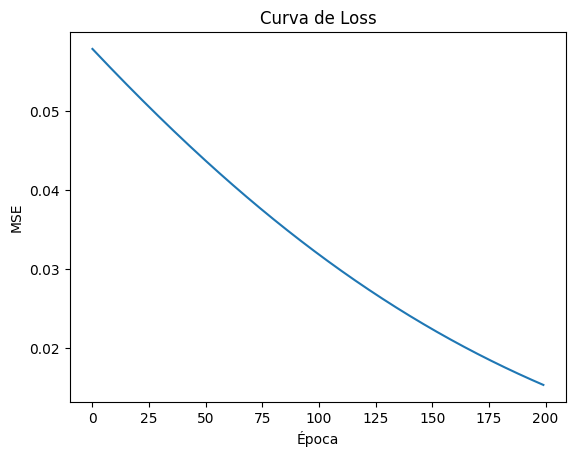

In [42]:
# curva de loss
plt.plot(losses)
plt.title("Curva de Loss")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.show()